### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

In [10]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,1~3,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [11]:
data.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
car                     0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

3. Decide what to do about your missing data -- drop, replace, other...

In [7]:
data = data.fillna(data.mode().iloc[0])

4. What proportion of the total observations chose to accept the coupon?



In [8]:
data.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
car                     0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

In [12]:
acceptance_rate = data['Y'].value_counts(normalize=True)
print(acceptance_rate)

Y
1    0.568433
0    0.431567
Name: proportion, dtype: float64


5. Use a bar plot to visualize the `coupon` column.

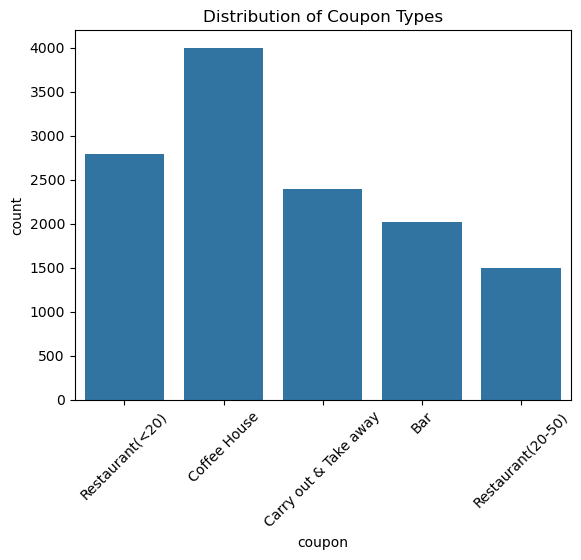

In [13]:
sns.countplot(data=data, x='coupon')
plt.xticks(rotation=45)
plt.title('Distribution of Coupon Types')
plt.show()

6. Use a histogram to visualize the temperature column.

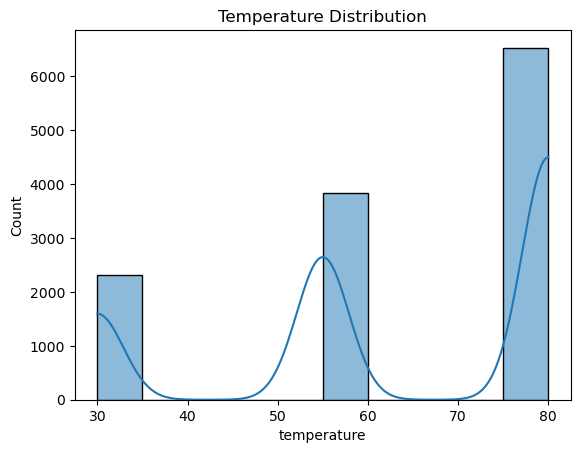

In [14]:
sns.histplot(data=data, x='temperature', bins=10, kde=True)
plt.title('Temperature Distribution')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [17]:
bar_data = data[data['coupon'] == 'Bar']

2. What proportion of bar coupons were accepted?


In [18]:
bar_acceptance_rate = bar_data['Y'].value_counts(normalize=True)
print(bar_acceptance_rate)

Y
0    0.589985
1    0.410015
Name: proportion, dtype: float64


3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [43]:
bar_data.loc[:, 'bar_freq'] = bar_data['Bar'].map({
    'never': 0,
    'less1': 0.5,
    '1~3': 2,
    '4~8': 6,
    'gt8': 10
})

low_freq = bar_data[bar_data['bar_freq'] <= 3]
high_freq = bar_data[bar_data['bar_freq'] > 3]

print("Low frequency acceptance rate:", low_freq['Y'].value_counts(normalize=True))
print("High frequency acceptance rate:", high_freq['Y'].value_counts(normalize=True))

Low frequency acceptance rate: Y
0    0.629263
1    0.370737
Name: proportion, dtype: float64
High frequency acceptance rate: Y
1    0.768844
0    0.231156
Name: proportion, dtype: float64


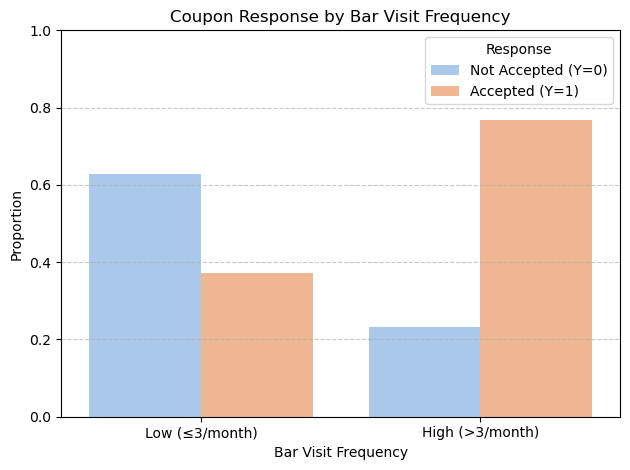

In [22]:
plot_data = pd.DataFrame({
    'Bar Visit Frequency': ['Low (≤3/month)', 'Low (≤3/month)', 'High (>3/month)', 'High (>3/month)'],
    'Response': ['Not Accepted (Y=0)', 'Accepted (Y=1)', 'Not Accepted (Y=0)', 'Accepted (Y=1)'],
    'Proportion': [
        low_freq['Y'].value_counts(normalize=True).get(0, 0),
        low_freq['Y'].value_counts(normalize=True).get(1, 0),
        high_freq['Y'].value_counts(normalize=True).get(0, 0),
        high_freq['Y'].value_counts(normalize=True).get(1, 0)
    ]
})

sns.barplot(data=plot_data, x='Bar Visit Frequency', y='Proportion', hue='Response', palette='pastel')
plt.title('Coupon Response by Bar Visit Frequency')
plt.ylabel('Proportion')
plt.xlabel('Bar Visit Frequency')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


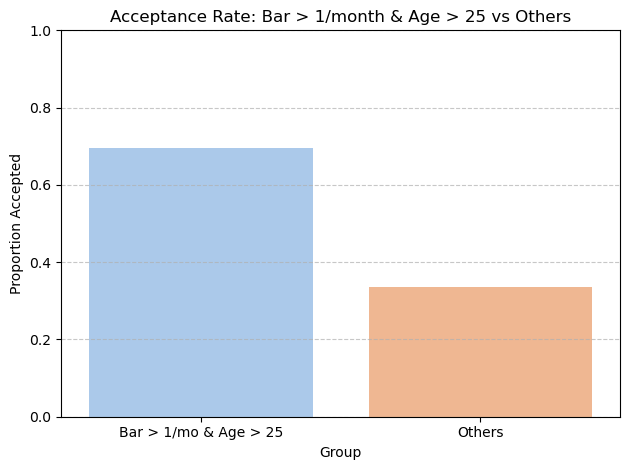

In [46]:


def extract_age(age_str):
    if pd.isna(age_str):
        return np.nan
    age_str = age_str.lower()
    if 'below' in age_str:
        return 20
    if '50plus' in age_str:
        return 51
    return int(age_str.split()[0])

bar_data.loc[:, 'age_num'] = bar_data['age'].apply(extract_age)


group_a = bar_data[(bar_data['bar_freq'] > 1) & (bar_data['age_num'] > 25)]
group_b = bar_data[~((bar_data['bar_freq'] > 1) & (bar_data['age_num'] > 25))]

group_a_accept = group_a['Y'].value_counts(normalize=True).get(1, 0)
group_b_accept = group_b['Y'].value_counts(normalize=True).get(1, 0)

compare_df = pd.DataFrame({
    'Group': ['Bar > 1/mo & Age > 25', 'Others'],
    'Acceptance Rate': [group_a_accept, group_b_accept]
})

sns.barplot(data=compare_df, x='Group', y='Acceptance Rate', hue='Group', palette='pastel')

plt.title('Acceptance Rate: Bar > 1/month & Age > 25 vs Others')
plt.ylim(0, 1)
plt.ylabel('Proportion Accepted')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [39]:
occupation_counts = data.groupby('occupation').size()
print("\nOccupation counts:")
print(occupation_counts)


Occupation counts:
occupation
Architecture & Engineering                    175
Arts Design Entertainment Sports & Media      629
Building & Grounds Cleaning & Maintenance      44
Business & Financial                          544
Community & Social Services                   241
Computer & Mathematical                      1408
Construction & Extraction                     154
Education&Training&Library                    943
Farming Fishing & Forestry                     43
Food Preparation & Serving Related            298
Healthcare Practitioners & Technical          244
Healthcare Support                            242
Installation Maintenance & Repair             133
Legal                                         219
Life Physical Social Science                  170
Management                                    838
Office & Administrative Support               639
Personal Care & Service                       175
Production Occupations                        110
Protective Service 

In [40]:
data = data.rename(columns={'passanger': 'passenger'})
passenger_counts = data.groupby('passenger').size()
print("\npassenger counts:")
print(passenger_counts)


passenger counts:
passenger
Alone        7305
Friend(s)    3298
Kid(s)       1006
Partner      1075
dtype: int64


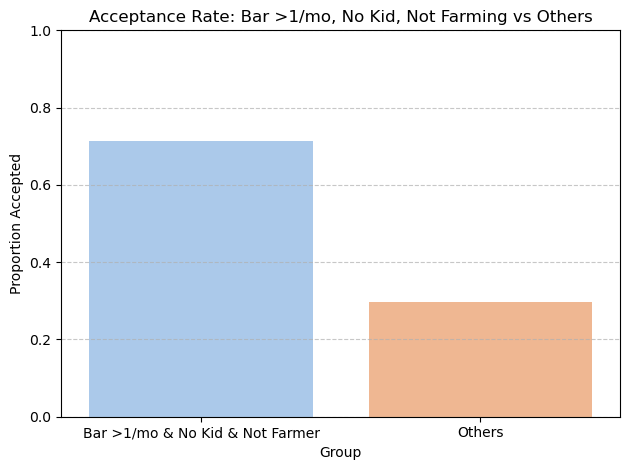

In [47]:
bar_data = data[data['coupon'] == 'Bar'].copy()
bar_data.loc[:, 'bar_freq'] = bar_data['Bar'].map({
    'never': 0,
    'less1': 0.5,
    '1~3': 2,
    '4~8': 6,
    'gt8': 10
})

group_a = bar_data[
    (bar_data['bar_freq'] > 1) &
    (bar_data['passenger'] != 'Kid(s)') &
    (bar_data['occupation'] != 'Farming Fishing & Forestry')
]

group_b = bar_data[~(
    (bar_data['bar_freq'] > 1) &
    (bar_data['passenger'] != 'Kid(s)') &
    (bar_data['occupation'] != 'Farming Fishing & Forestry')
)]

group_a_accept = group_a['Y'].value_counts(normalize=True).get(1, 0)
group_b_accept = group_b['Y'].value_counts(normalize=True).get(1, 0)

compare_df = pd.DataFrame({
    'Group': ['Bar >1/mo & No Kid & Not Farmer', 'Others'],
    'Acceptance Rate': [group_a_accept, group_b_accept]
})

sns.barplot(data=compare_df, x='Group', y='Acceptance Rate', palette='pastel', hue='Group', legend=False)
plt.title('Acceptance Rate: Bar >1/mo, No Kid, Not Farming vs Others')
plt.ylim(0, 1)
plt.ylabel('Proportion Accepted')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [54]:
data['bar_freq'] = data['Bar'].map({'never': 0, 'less1': 0.5, '1~3': 2, '4~8': 6, 'gt8': 10})
data['rest_freq'] = data['RestaurantLessThan20'].map({'never': 0, 'less1': 0.5, '1~3': 2, '4~8': 6, 'gt8': 10})

In [50]:
def income_to_number(income_str):
    if pd.isna(income_str): return np.nan
    income_str = income_str.replace('$', '').replace(',', '')
    try:
        lower = int(income_str.split('-')[0].strip())
        return lower
    except:
        if 'less than' in income_str.lower():
            return 0
        return 100000

data['income_num'] = data['income'].apply(income_to_number)

In [51]:
def extract_age(age_str):
    if pd.isna(age_str): return np.nan
    age_str = age_str.lower()
    if 'below' in age_str:
        return 20
    if '50plus' in age_str:
        return 51
    return int(age_str.split()[0])

data['age_num'] = data['age'].apply(extract_age)

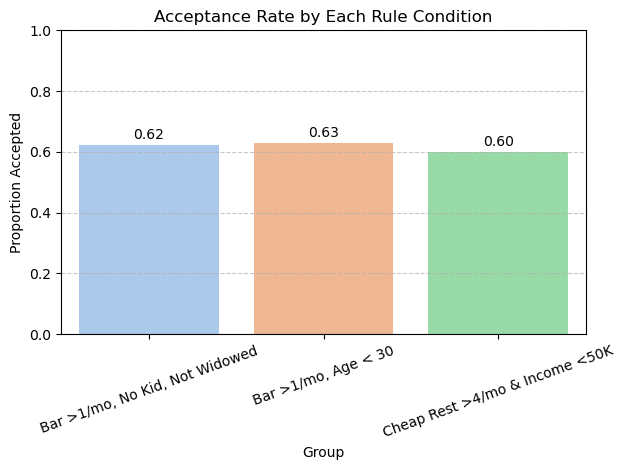

In [53]:
rule1 = (data['bar_freq'] > 1) & (data['passenger'] != 'Kid(s)') & (data['maritalStatus'] != 'Widowed')
rule2 = (data['bar_freq'] > 1) & (data['age_num'] < 30)
rule3 = (data['rest_freq'] > 4) & (data['income_num'] < 50000)

# Calculate acceptance rates for each group
rate1 = data[rule1]['Y'].value_counts(normalize=True).get(1, 0)
rate2 = data[rule2]['Y'].value_counts(normalize=True).get(1, 0)
rate3 = data[rule3]['Y'].value_counts(normalize=True).get(1, 0)

compare_df = pd.DataFrame({
    'Group': [
        'Bar >1/mo, No Kid, Not Widowed',
        'Bar >1/mo, Age < 30',
        'Cheap Rest >4/mo & Income <50K'
    ],
    'Acceptance Rate': [rate1, rate2, rate3]
})

# Plotting
sns.barplot(data=compare_df, x='Group', y='Acceptance Rate', hue='Group', palette='pastel', legend=False)
plt.title('Acceptance Rate by Each Rule Condition')
plt.ylim(0, 1)
plt.ylabel('Proportion Accepted')
plt.xticks(rotation=20)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate each bar
for index, row in compare_df.iterrows():
    plt.text(index, row['Acceptance Rate'] + 0.02, f"{row['Acceptance Rate']:.2f}", ha='center')

plt.tight_layout()
plt.show()

7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [56]:
print ("The acceptance rates are very similar between drivers who go to bars more than once a month and those who dine at cheap restaurants more than four times a month.")

The acceptance rates are very similar between drivers who go to bars more than once a month and those who dine at cheap restaurants more than four times a month.


In [57]:
print("Among drivers who go to bars more than once a month, the acceptance rate is similar between those who are under 30 and those who had non-child passengers and are not widowed.")

Among drivers who go to bars more than once a month, the acceptance rate is similar between those who are under 30 and those who had non-child passengers and are not widowed.


### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

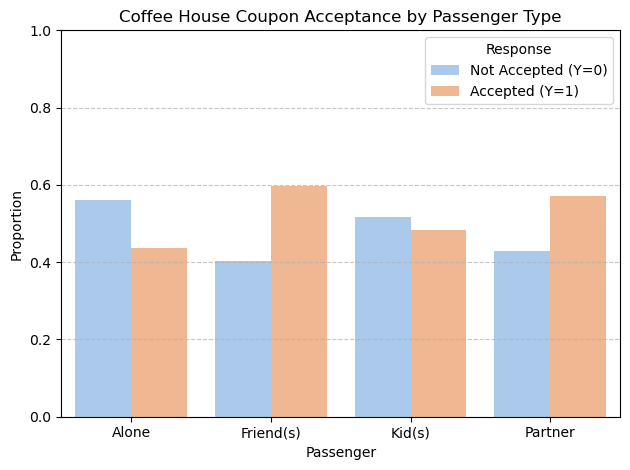

In [58]:
coffee_data = data[data['coupon'] == 'Coffee House'].copy()

# Calculate acceptance rate per passenger group
acceptance_by_passenger = coffee_data.groupby('passenger')['Y'].value_counts(normalize=True).unstack().fillna(0)
acceptance_by_passenger.columns = ['Not Accepted (Y=0)', 'Accepted (Y=1)']
acceptance_by_passenger = acceptance_by_passenger.reset_index().melt(id_vars='passenger', var_name='Response', value_name='Proportion')

# Plot the results
sns.barplot(data=acceptance_by_passenger, x='passenger', y='Proportion', hue='Response', palette='pastel')
plt.title('Coffee House Coupon Acceptance by Passenger Type')
plt.ylabel('Proportion')
plt.xlabel('Passenger')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [60]:
print("running some analysis on Coffee column")

running some analysis on Coffee column


In [61]:
print("it seems like the acceptance rate is higher for those who are with friends, or have a partner, compared to those who are alone, or who have kids")

it seems like the acceptance rate is higher for those who are with friends, or have a partner, compared to those who are alone, or who have kids


In [62]:
print("which indicates that people who are alone or have kids tend to go to the coffee shops less than others")

which indicates that people who are alone or have kids tend to go to the coffee shops less than others
